In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# transforms.ToTensor() converts images to PyTorch tensors (values 0-1)
# Normalize() standardizes pixel values — helps training converge faster
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:11<00:00, 896kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 105kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 966kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Training samples: 60000
Test samples:     10000


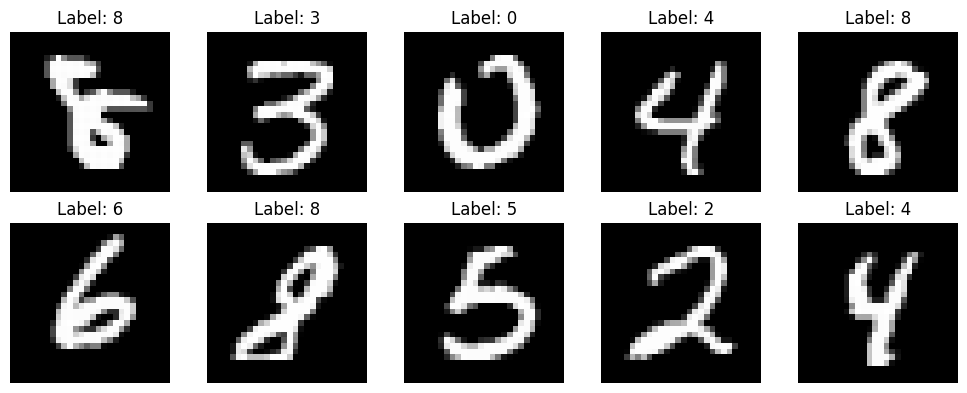

In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        # Conv layers: learn spatial features (edges, curves)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers: combine features → class scores
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes (digits 0-9)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28x28 → 14x14
        x = self.pool(self.relu(self.conv2(x)))  # 14x14 → 7x7
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)              # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                          # raw scores (logits)
        return x

model = MNISTNet()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MNISTNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
criterion = nn.CrossEntropyLoss()        # loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()         # clear old gradients
        outputs = model(images)       # forward pass
        loss = criterion(outputs, labels)
        loss.backward()               # backpropagation
        optimizer.step()              # update weights
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    with torch.no_grad():             # no gradient tracking needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
    return correct / len(loader.dataset) * 100

# Train for 5 epochs and track metrics
train_losses, test_accuracies = [], []

for epoch in range(5):
    loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    acc  = evaluate(model, test_loader, device)
    train_losses.append(loss)
    test_accuracies.append(acc)
    print(f"Epoch {epoch+1}/5 — Loss: {loss:.4f} | Test Accuracy: {acc:.2f}%")

Using device: cpu
Epoch 1/5 — Loss: 0.1403 | Test Accuracy: 98.68%
Epoch 2/5 — Loss: 0.0466 | Test Accuracy: 99.03%
Epoch 3/5 — Loss: 0.0347 | Test Accuracy: 99.19%
Epoch 4/5 — Loss: 0.0283 | Test Accuracy: 99.08%
Epoch 5/5 — Loss: 0.0221 | Test Accuracy: 99.10%


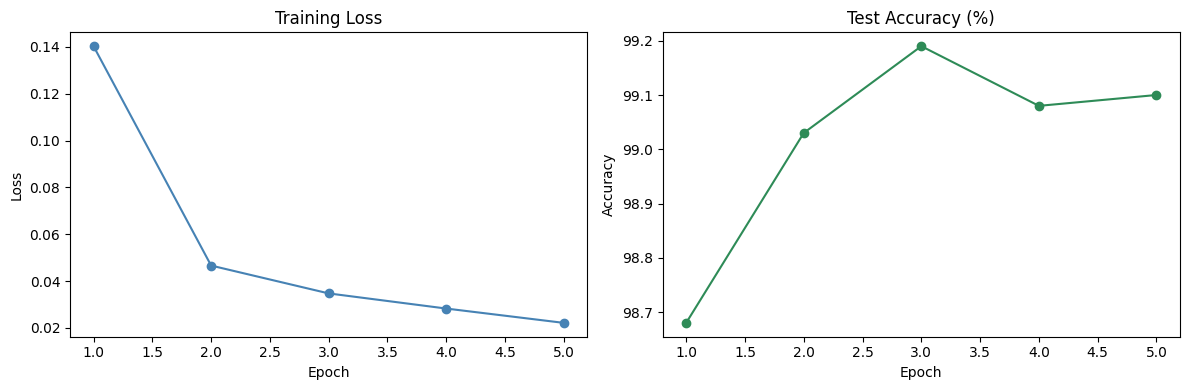


Final accuracy: 99.10%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 6), train_losses, marker='o', color='steelblue')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(range(1, 6), test_accuracies, marker='o', color='seagreen')
ax2.set_title("Test Accuracy (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig('../models/centralized_baseline.png', dpi=150)
plt.show()
print(f"\nFinal accuracy: {test_accuracies[-1]:.2f}%")

In [7]:
torch.save(model.state_dict(), '../models/mnist_centralized.pth')
print("Model saved. This is your centralized baseline.")
print("In FL, each client will train a copy of this same architecture.")

Model saved. This is your centralized baseline.
In FL, each client will train a copy of this same architecture.
